# UNO Card Detection — Card Type + Position

This notebook trains an object detector on generated images using `placements_*.csv`.

- **Task**: predict each card's class and bounding box
- **Labels**: from `data/images_generee/placements_*.csv`
- **Model**: Faster R-CNN MobileNetV3 (trained from scratch)

In [1]:
# ── Install dependencies ───────────────────────────────────────────────────
import sys, platform

os_name = platform.system().lower()
if os_name == 'darwin' or os_name == 'windows':
    %pip install torch torchvision torchaudio -q
else:  # Linux
    %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q

%pip install numpy matplotlib pillow pandas scikit-learn tqdm -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%reload_ext autoreload
%autoreload 2

import os
import csv
from pathlib import Path
from collections import Counter, defaultdict
from functools import lru_cache

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image, ImageFilter

import dl_dataset as ds

import torchvision
from torchvision import transforms as T
from torchvision.transforms import functional as F

print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

PyTorch 2.10.0+cu128 | torchvision 0.25.0+cu128
Using device: cuda


## 1. Dataset Overview

In [3]:
CSV_DIR = Path('../data/images_generee')
placement_csvs = sorted(CSV_DIR.glob('placements_*.csv'))
if not placement_csvs:
    raise FileNotFoundError(
        "No placements_*.csv found in data/images_generee. Run generate_large_images.py first."
    )

CSV_PATH = placement_csvs[-1]
IMG_DIR = CSV_DIR
CROP_DIR = Path('../data/images_crop')

CANVAS_W = 4000
CANVAS_H = 2662

with open(CSV_PATH) as f:
    rows = list(csv.DictReader(f))

placements_by_image = defaultdict(list)
card_counts = Counter()
for r in rows:
    placements_by_image[r["big_image"]].append(r)
    card_counts[r["card_type"]] += 1

image_ids = sorted(placements_by_image.keys())

print(f"Using placements: {CSV_PATH}")
print(f"{len(rows)} placements across {len(image_ids)} images")
print(f"{ds.NUM_CLASSES} card classes: {ds.CARD_CLASSES[:5]}...")

least_seen = sorted(card_counts, key=card_counts.get)[:5]
most_seen  = sorted(card_counts, key=card_counts.get, reverse=True)[:5]
print(f"  5 rarest : {[(c, card_counts[c]) for c in least_seen]}")
print(f"  5 most   : {[(c, card_counts[c]) for c in most_seen]}")

def find_crop_path(card_type, crop_dir=CROP_DIR):
    for ext in (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"):
        p = crop_dir / f"{card_type}{ext}"
        if p.exists():
            return p
    return None

@lru_cache(maxsize=4096)
def rotated_size(card_type, angle_deg):
    p = find_crop_path(card_type)
    if p is None:
        return None
    im = Image.open(p).convert("RGBA")
    rotated = im.rotate(angle_deg, expand=True, resample=Image.BICUBIC)
    if rotated.width > CANVAS_W or rotated.height > CANVAS_H:
        rotated = im.rotate(angle_deg, expand=False, resample=Image.BICUBIC)
    return rotated.width, rotated.height

Using placements: ../data/images_generee/placements_1778793286.csv
90022 placements across 10000 images
54 card classes: ['b_0', 'b_1', 'b_2', 'b_3', 'b_4']...
  5 rarest : [('b_6', 1538), ('wild', 1577), ('y_0', 1579), ('g_3', 1601), ('b_reverse', 1612)]
  5 most   : [('y_draw_2', 1742), ('b_1', 1735), ('r_skip', 1720), ('r_reverse', 1719), ('g_0', 1718)]


## 2. Visualise Placements

Draw the placement boxes derived from the CSV to confirm geometry.

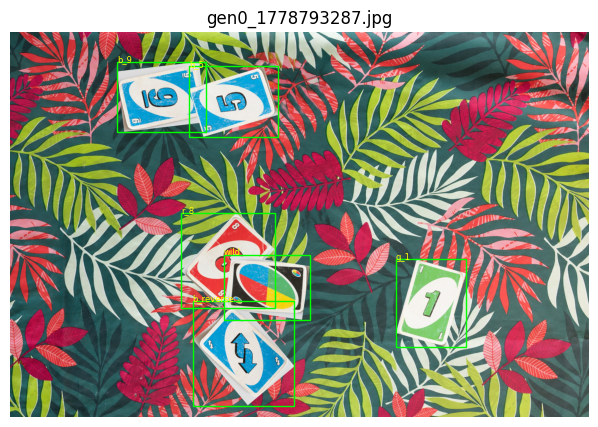

In [4]:
sample_id = image_ids[0]  # change to any image filename
img_path = IMG_DIR / sample_id
img = Image.open(img_path).convert("RGB")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.imshow(img)

for r in placements_by_image[sample_id]:
    card = r["card_type"]
    angle = float(r["angle_deg"])
    size = rotated_size(card, angle)
    if size is None:
        continue
    w, h = size
    x = float(r["x"])
    y = float(r["y"])
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor="lime", facecolor="none")
    ax.add_patch(rect)
    ax.text(x, y, card, color="yellow", fontsize=6)

ax.set_title(sample_id)
ax.axis("off")
plt.show()

## 3. Build Detection Datasets

We train on full images with bounding boxes. Images are resized to a smaller
resolution and boxes are scaled accordingly.

In [5]:
import random

TARGET_W = 800
TARGET_H = int(CANVAS_H * TARGET_W / CANVAS_W)

AUG_FLIP_P = 0.5
AUG_JITTER_P = 0.8
AUG_BLUR_P = 0.2
AUG_NOISE_P = 0.2

class UNOPlacementDataset(Dataset):
    def __init__(self, image_ids, placements_by_image, images_dir, target_size=(TARGET_W, TARGET_H), augment=False):
        self.image_ids = image_ids
        self.placements_by_image = placements_by_image
        self.images_dir = Path(images_dir)
        self.target_size = target_size
        self.augment = augment
        self.color_jitter = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05)

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_name = self.image_ids[idx]
        img_path = self.images_dir / img_name
        img = Image.open(img_path).convert("RGB")

        boxes = []
        labels = []
        for r in self.placements_by_image[img_name]:
            card = r["card_type"]
            label = ds.CARD_TO_IDX.get(card)
            if label is None:
                continue
            angle = float(r["angle_deg"])
            size = rotated_size(card, angle)
            if size is None:
                continue
            w, h = size
            x = float(r["x"])
            y = float(r["y"])
            boxes.append([x, y, x + w, y + h])
            labels.append(label + 1)  # background = 0

        if boxes:
            boxes = torch.tensor(boxes, dtype=torch.float32)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        if self.augment:
            if random.random() < AUG_FLIP_P:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
                if len(boxes) > 0:
                    w = img.width
                    x1 = boxes[:, 0].clone()
                    x2 = boxes[:, 2].clone()
                    boxes[:, 0] = w - x2
                    boxes[:, 2] = w - x1

            if random.random() < AUG_JITTER_P:
                img = self.color_jitter(img)

            if random.random() < AUG_BLUR_P:
                img = img.filter(ImageFilter.GaussianBlur(radius=1.0))

        if self.target_size is not None:
            target_w, target_h = self.target_size
            scale_x = target_w / img.width
            scale_y = target_h / img.height
            img = img.resize((target_w, target_h), resample=Image.BILINEAR)
            if len(boxes) > 0:
                boxes[:, [0, 2]] *= scale_x
                boxes[:, [1, 3]] *= scale_y

        img_tensor = F.to_tensor(img)
        if self.augment and random.random() < AUG_NOISE_P:
            noise = torch.randn_like(img_tensor) * 0.03
            img_tensor = torch.clamp(img_tensor + noise, 0.0, 1.0)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
        }
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

random.seed(42)
indices = list(range(len(image_ids)))
random.shuffle(indices)

n_train = int(len(indices) * 0.8)
train_ids = [image_ids[i] for i in indices[:n_train]]
val_ids   = [image_ids[i] for i in indices[n_train:]]

train_ds = UNOPlacementDataset(train_ids, placements_by_image, IMG_DIR, augment=True)
val_ds   = UNOPlacementDataset(val_ids, placements_by_image, IMG_DIR, augment=False)

BATCH_SIZE = 6
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn
 )
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn
 )

print(f"Train images: {len(train_ds)} | Val images: {len(val_ds)}")

Train images: 8000 | Val images: 2000


## 4. Model

We use a lightweight Faster R-CNN with MobileNetV3 backbone and train from scratch.
The detector predicts class + bounding box for each card.

In [6]:
num_classes = ds.NUM_CLASSES + 1  # +1 for background
DROPOUT_P = 0.3

class FastRCNNPredictorDropout(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_p=DROPOUT_P):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout_p)
        self.cls_score = nn.Linear(in_channels, num_classes)
        self.bbox_pred = nn.Linear(in_channels, num_classes * 4)

    def forward(self, x):
        if x.dim() == 4:
            x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)
        scores = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas

model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(
    weights=None,
    weights_backbone=None,
 )

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictorDropout(in_features, num_classes)

# Match the resize used in the dataset (shorter side = TARGET_H)
model.transform.min_size = (TARGET_H,)
model.transform.max_size = TARGET_W

print(f"Detector classes (incl. background): {num_classes}")

Detector classes (incl. background): 55


## 5. Training

We optimize the standard detection losses (classification + box regression),
with data augmentation, dropout, weight decay, LR scheduling, and early stopping.

In [7]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(1, len(loader))

@torch.no_grad()
def eval_loss(model, loader, device):
    model.train()  # keep train mode to get losses
    total_loss = 0.0
    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets) # return a dictionary of losses for each image in the batch, 
        total_loss += sum(loss_dict.values()).item()
    return total_loss / max(1, len(loader))

NUM_EPOCHS = 10
LR = 3e-4
WEIGHT_DECAY = 5e-4
CHECKPOINT = "uno_detector.pth"
PATIENCE = 3

model = model.to(DEVICE)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

best_val = float("inf")
bad_epochs = 0

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss = eval_loss(model, val_loader, DEVICE)
    scheduler.step(val_loss)
    print(f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f}")

    if val_loss < best_val - 1e-4:
        best_val = val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f"Saved best checkpoint to {CHECKPOINT}")
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print("Early stopping: no val improvement.")
            break

print(f"Best val loss: {best_val:.4f}")

Epoch 01/10 | train=1.8416 | val=1.3788
Saved best checkpoint to uno_detector.pth
Epoch 02/10 | train=1.2459 | val=1.2007
Saved best checkpoint to uno_detector.pth
Epoch 03/10 | train=0.9576 | val=0.8384
Saved best checkpoint to uno_detector.pth
Epoch 04/10 | train=0.8171 | val=0.7521
Saved best checkpoint to uno_detector.pth
Epoch 05/10 | train=0.7466 | val=0.7712
Epoch 06/10 | train=0.6894 | val=0.6694
Saved best checkpoint to uno_detector.pth
Epoch 07/10 | train=0.6224 | val=0.6695
Epoch 08/10 | train=0.5911 | val=0.5972
Saved best checkpoint to uno_detector.pth
Epoch 09/10 | train=0.5652 | val=0.5847
Saved best checkpoint to uno_detector.pth
Epoch 10/10 | train=0.5306 | val=0.5866
Best val loss: 0.5847


## 6. Qualitative Predictions

Visualize a few validation images with predicted boxes and labels.

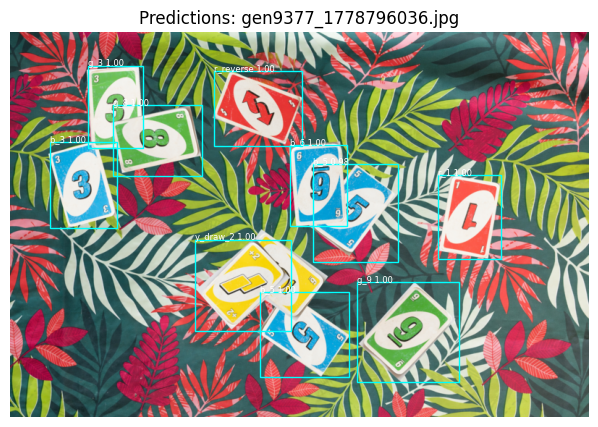

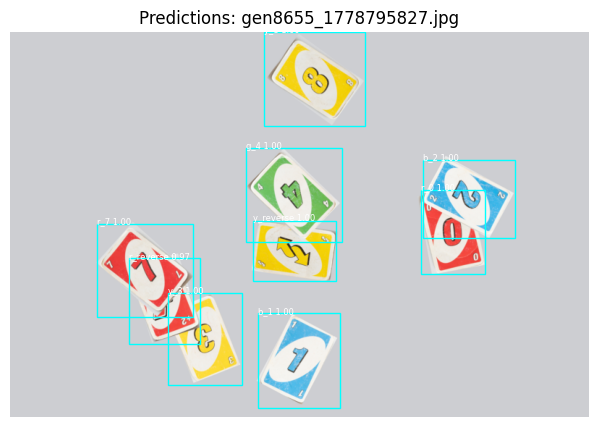

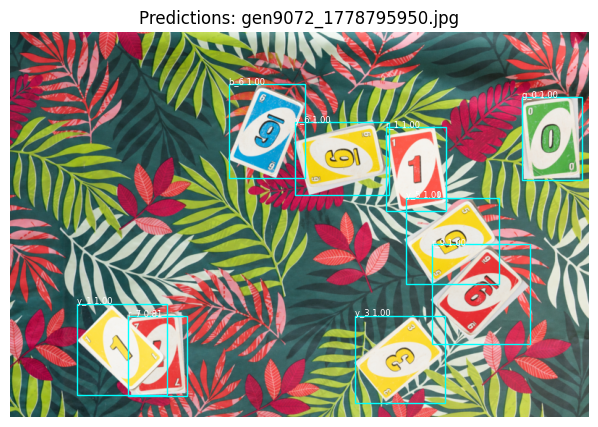

In [8]:
idx_to_card = {i + 1: name for i, name in enumerate(ds.CARD_CLASSES)}

def show_predictions(img_name, score_thresh=0.5):
    img = Image.open(IMG_DIR / img_name).convert("RGB")
    img = img.resize((TARGET_W, TARGET_H), resample=Image.BILINEAR)
    tensor = F.to_tensor(img).to(DEVICE)

    model.eval()
    preds = model([tensor])[0]
    boxes = preds["boxes"].detach().cpu().numpy()
    labels = preds["labels"].detach().cpu().numpy()
    scores = preds["scores"].detach().cpu().numpy()

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.imshow(img)
    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1, edgecolor="cyan", facecolor="none"
        )
        ax.add_patch(rect)
        name = idx_to_card.get(int(label), "?")
        ax.text(x1, y1, f"{name} {score:.2f}", color="white", fontsize=6)

    ax.set_title(f"Predictions: {img_name}")
    ax.axis("off")
    plt.show()

for img_name in val_ids[:3]:
    show_predictions(img_name, score_thresh=0.5)